In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
import shap

### Loading df

In [9]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615957,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615958,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615959,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615960,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615961,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df_yoy = pd.read_csv('../Dataset/Processed/Merged_Dataset_yoy.csv')
df_yoy['Date'] = pd.to_datetime(df_yoy['Date'])
df_yoy.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615932,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615933,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615934,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615935,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615936,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
num_companies = df['Company'].nunique()
print(f"Number of companies in the dataset: {num_companies}")

oldest_date = df['Date'].min()
print(f"Oldest date in the dataset: {oldest_date}")

Number of companies in the dataset: 186
Oldest date in the dataset: 2009-09-18 00:00:00


In [3]:
features = [
    'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 
    'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 
    'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 
    'Brent_Close', 'Brent_Volume', 'OVX_Close', 
    'TTF_Gas_Close', 'VIX_Close', 'Gold_Close'
]

targets = ['EBITDA', 'ROA', 'Net_Income']

# Feature Selection & Target Engineering Pipeline
This section of the study aims to identify the most predictive features (market data and macroeconomic indicators) for forecasting corporate fundamental targets (EBITDA, ROA, Net Income). Because the dataset contains sequential financial data, 90-day lookback windows prior to each financial report release are extracted, calculating the **mean** (Level/Trend) and **standard deviation** (Volatility/Shock)for each feature.

To ensure robust and unbiased feature selection, three distinct mathematical frameworks are employed:

**1. Mutual Information**

Mutual Information (MI) is a non-parametric metric that measures the reduction in uncertainty about the target variable given the knowledge of a specific feature. Unlike traditional Pearson correlation, MI is completely model-agnostic and can capture complex, non-linear relationships between macroeconomic shocks and corporate fundamentals.

**2. Random Forest & Gini Importance**

Random Forest is an ensemble learning method and the feature importance is calculated using the Gini Importance (Mean Decrease in Impurity) metric. 
It calculates how much each feature contributes to reducing the variance (in regression) or impurity (in classification) across all the decision trees in the forest. It provides an excellent measure of the absolute predictive power of a variable.

**3. SHAP Values**

While Random Forest shows how much a feature matters, SHAP (SHapley Additive exPlanations) explains how it matters: it values break down the prediction to show the directional impact of each feature. A SHAP summary plot allows us to visually understand whether a high value of a specific feature pushes the model's prediction higher or lower, providing crucial economic interpretability to our black-box models. Red dots indicate that a high value of the feature increases the probability of an upward trend, while blue dots indicate that a high value decreases it. If the dots are on the right side of the plot, it means that the feature pushes the prediction towards an upward trend; if they are on the left, it means that the feature pushes the prediction towards a downward trend.

## Part 1: Absolute Target Analysis - Regression

In this first analytical phase, the algorithms are tasked with predicting the absolute values of the financial targets. 

This approach serves as a baseline to test the models' behavior on raw, unscaled accounting data. We treat this as a continuous Regression problem using `RandomForestRegressor` and `mutual_info_regression`.

In [ ]:
param_distributions = {
    'n_estimators': [400, 700, 1000, 1300],
    'max_depth': [None, 10, 16, 24, 32],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap': [True],
    'criterion': ['squared_error', 'absolute_error']
}

def fit_rf(X_train_local, y_train_local):
    base_rf = RandomForestRegressor(random_state=42, oob_score=False)
    rf_search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=param_distributions,
        n_iter=35,
        cv=4,
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1
    )
    rf_search.fit(X_train_local, y_train_local)
    return rf_search.best_estimator_, rf_search.best_params_

def signed_log_transform(y):
    return np.sign(y) * np.log1p(np.abs(y))

def signed_log_inverse(y):
    return np.sign(y) * np.expm1(np.abs(y))

def regression_metrics(y_true, y_pred):
    eps = 1e-8
    abs_err = np.abs(y_pred - y_true)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    avg_pct_diff = float(np.mean(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    median_pct_diff = float(np.median(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    wape = float(np.sum(abs_err) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)
    smape = float(
        np.mean(2.0 * abs_err / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'AvgPctDiff': avg_pct_diff,
        'MedianPctDiff': median_pct_diff,
        'WAPE': wape,
        'sMAPE': smape
    }

def fit_xgb_classifier(X_train_scaled, y_train):
    # Calculate class imbalance ratio for XGBoost (equivalent to class_weight='balanced')
    # Formula: sum(negative instances) / sum(positive instances)
    imbalance_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
    
    # Define the base XGBoost classifier
    base_xgb = xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        scale_pos_weight=imbalance_ratio,
        n_jobs=-1
    )
    
    # Define the hyperparameter grid specific to Gradient Boosting
    # Note: XGBoost prefers shallower trees (max_depth 3-6) compared to Random Forest
    param_distributions = {
        'n_estimators': [200, 400, 600, 800, 1000],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],           # Percentage of rows used per tree
        'colsample_bytree': [0.6, 0.8, 1.0],    # Percentage of columns used per tree
        'gamma': [0, 0.1, 0.5, 1, 5]            # Regularization parameter to prevent overfitting
    }
    
    # Initialize RandomizedSearchCV (150 iterations * 4 folds = 600 fits per target)
    xgb_search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_distributions,
        n_iter=150,
        cv=4,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1  # Set to 1 for a clean progress bar without flooding the screen
    )
    
    # Train the tuner
    xgb_search.fit(X_train_scaled, y_train)
    
    return xgb_search.best_estimator_, xgb_search.best_params_

### Exogenous Variables Only without one hot encoding of the company


                                EBITDA                                
Total valid 90-day windows extracted: 4446

Model comparison (test metrics):
Raw Target RF  -> R2: 0.7706 | MAE: 357376.1894 | RMSE: 1330620.0299 | Avg % Diff: 804.71% | WAPE: 45.77% | sMAPE: 80.63%
Signed-Log RF  -> R2: 0.0940 | MAE: 646156.3358 | RMSE: 2644340.1730 | Avg % Diff: 341.97% | WAPE: 82.75% | sMAPE: 100.86%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 237884.2656 | RMSE: 911665.9955 | R2: 0.8832 | Avg % Diff: 322.55% | Median % Diff: 40.90% | WAPE: 30.54% | sMAPE: 63.90%
Test  -> MAE: 357376.1894 | RMSE: 1330620.0299 | R2: 0.7706 | Avg % Diff: 804.71% | Median % Diff: 62.51% | WAPE: 45.77% | sMAPE: 80.63%

Sample of predicted vs actual values for EBITDA:
   Actual    Predicted   Abs_Error   Pct_Diff

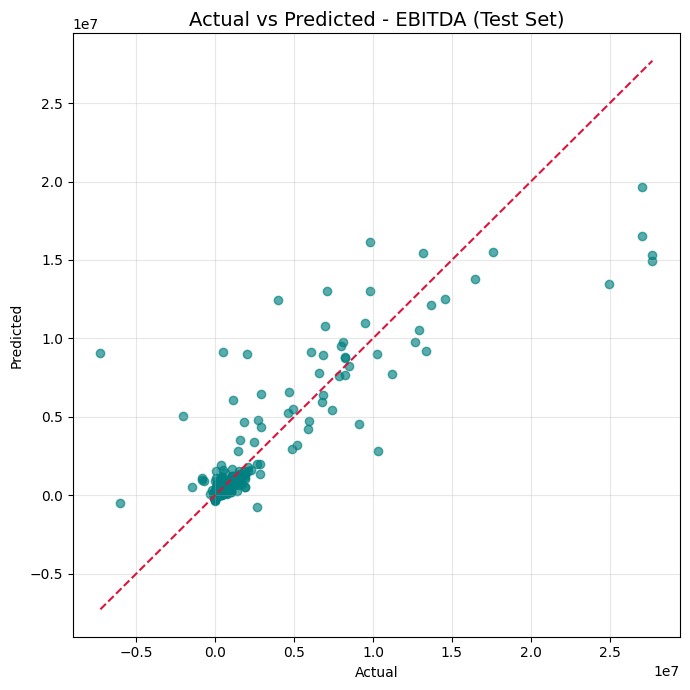

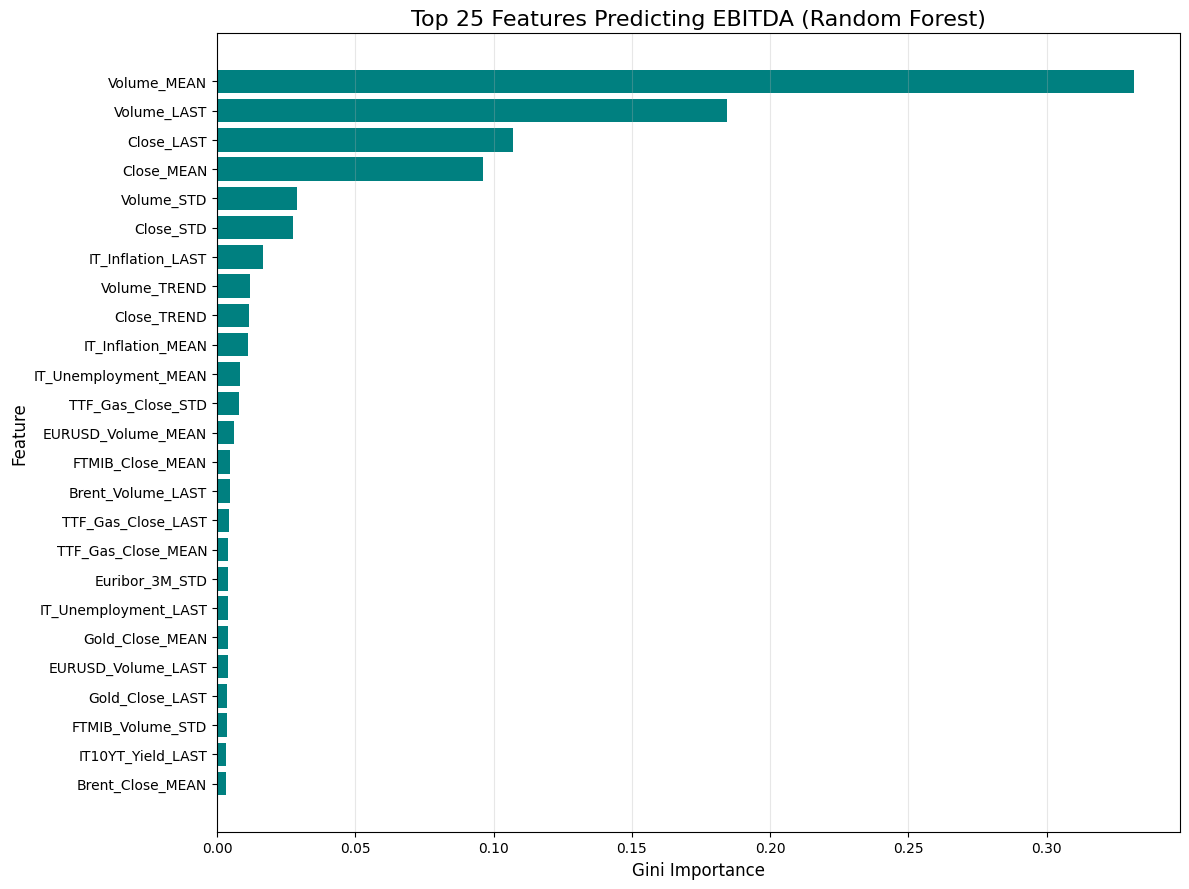

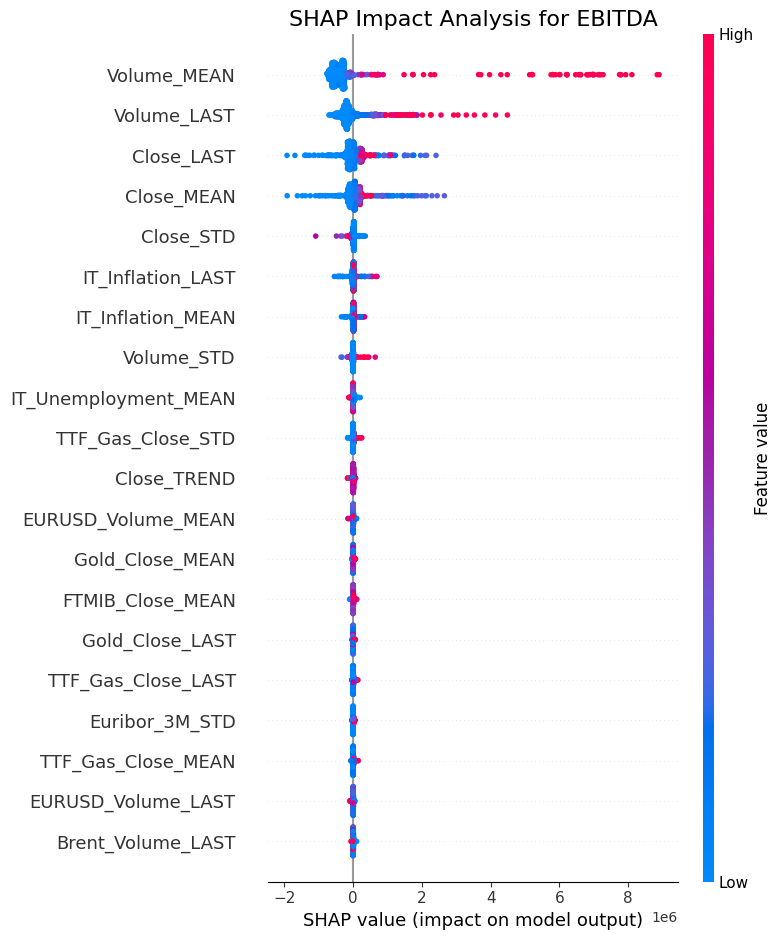


                                 ROA                                  
Total valid 90-day windows extracted: 4500

Model comparison (test metrics):
Raw Target RF  -> R2: -3.8307 | MAE: 0.0643 | RMSE: 0.2941 | Avg % Diff: 289.75% | WAPE: 116.01% | sMAPE: 108.40%
Signed-Log RF  -> R2: -0.2660 | MAE: 0.0510 | RMSE: 0.1506 | Avg % Diff: 222.16% | WAPE: 92.02% | sMAPE: 108.28%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0630 | RMSE: 0.6193 | R2: 0.4776 | Avg % Diff: 192.12% | Median % Diff: 68.69% | WAPE: 71.52% | sMAPE: 97.22%
Test  -> MAE: 0.0510 | RMSE: 0.1506 | R2: -0.2660 | Avg % Diff: 222.16% | Median % Diff: 78.91% | WAPE: 92.02% | sMAPE: 108.28%

Sample of predicted vs actual values for ROA:
   Actual  Predicted  Abs_Error  Pct_Diff_%
-0.008322   0.006592   0.014914  179.208763
-0.0

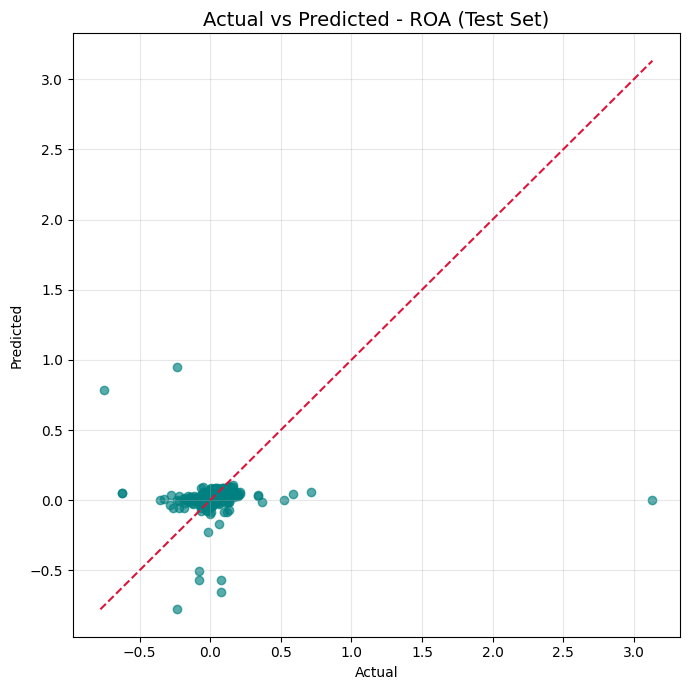

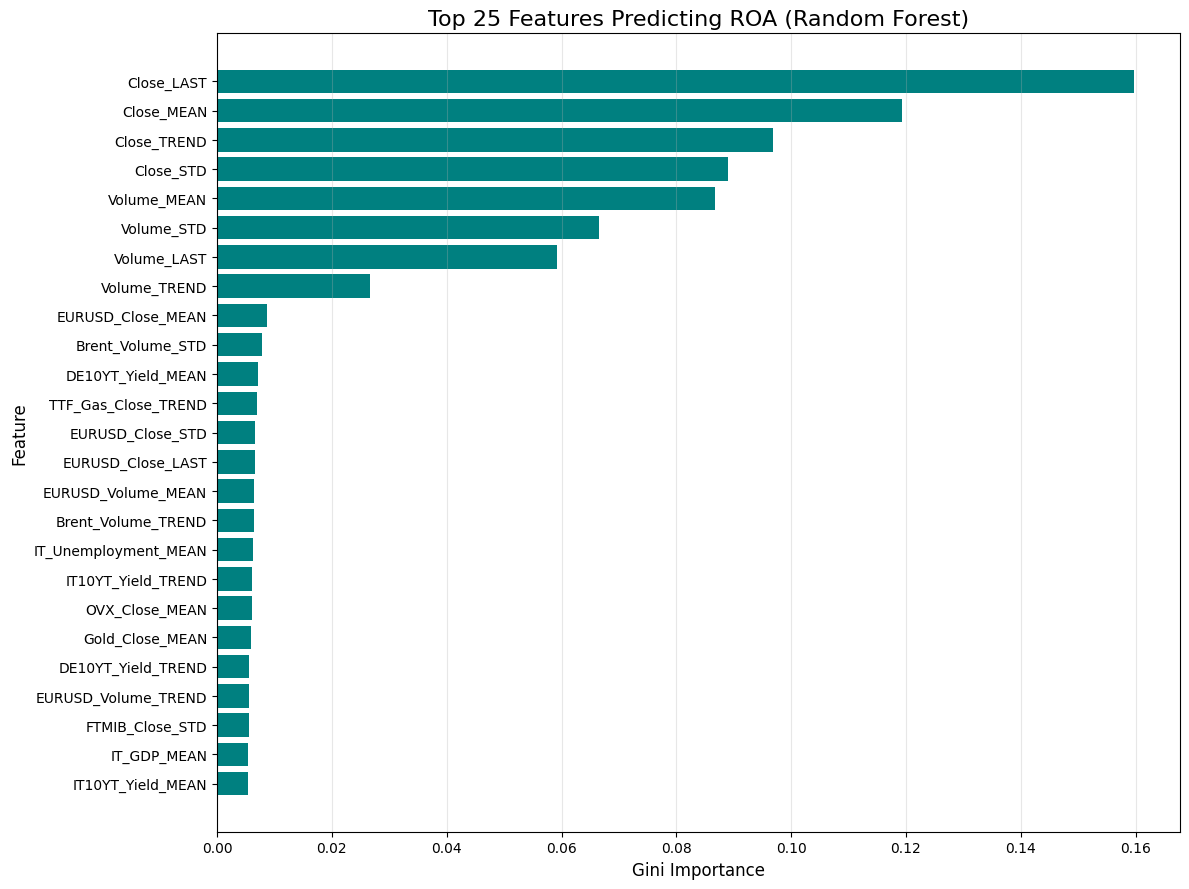

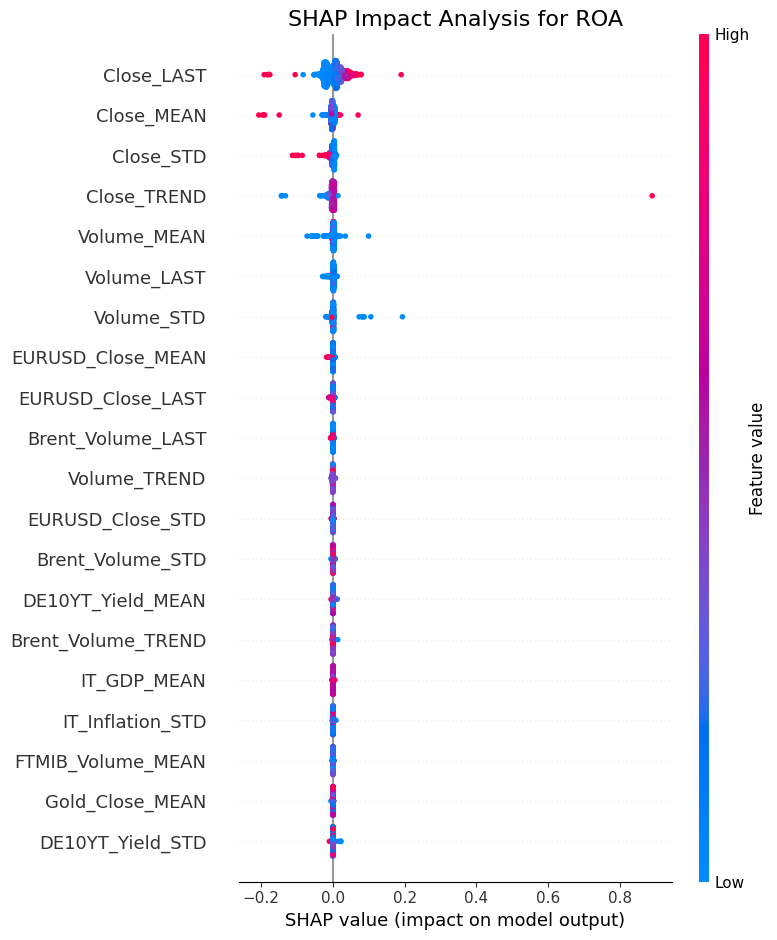


                              Net_Income                              
Total valid 90-day windows extracted: 4503

Model comparison (test metrics):
Raw Target RF  -> R2: 0.5934 | MAE: 202051.8807 | RMSE: 709040.8309 | Avg % Diff: 501.24% | WAPE: 63.04% | sMAPE: 105.18%
Signed-Log RF  -> R2: 0.1783 | MAE: 264630.0697 | RMSE: 1007932.9964 | Avg % Diff: 136.49% | WAPE: 82.56% | sMAPE: 134.95%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 156709.3281 | RMSE: 660205.8567 | R2: 0.7461 | Avg % Diff: 599.17% | Median % Diff: 48.79% | WAPE: 45.87% | sMAPE: 75.66%
Test  -> MAE: 202051.8807 | RMSE: 709040.8309 | R2: 0.5934 | Avg % Diff: 501.24% | Median % Diff: 80.18% | WAPE: 63.04% | sMAPE: 105.18%

Sample of predicted vs actual values for Net_Income:
    Actual    Predicted    Abs_Er

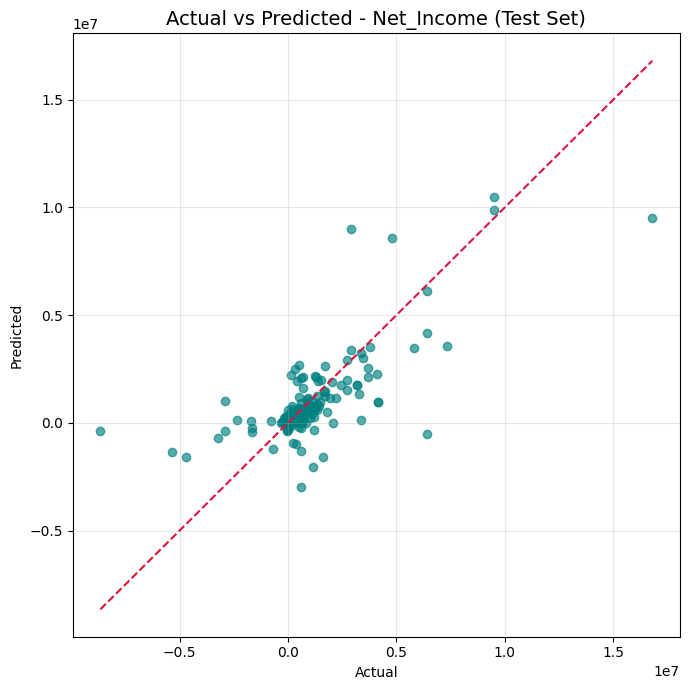

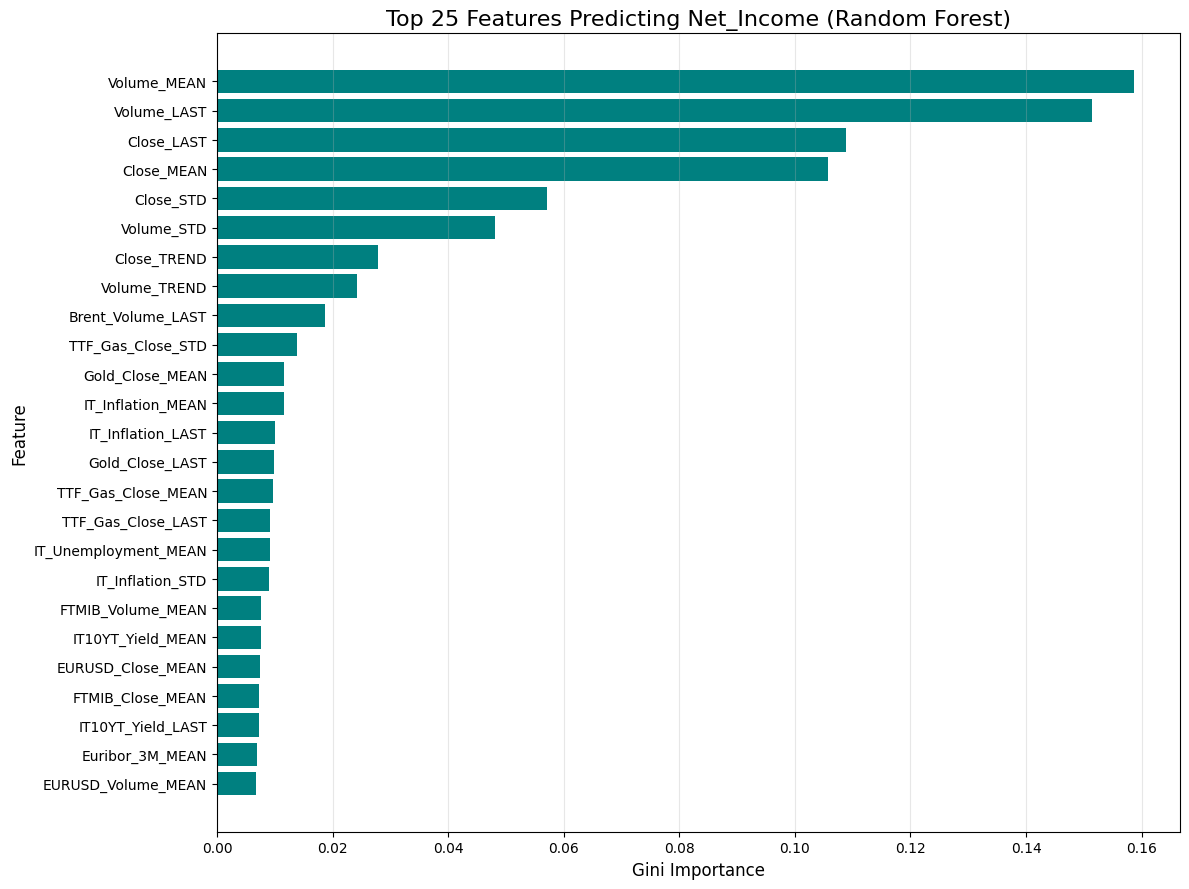

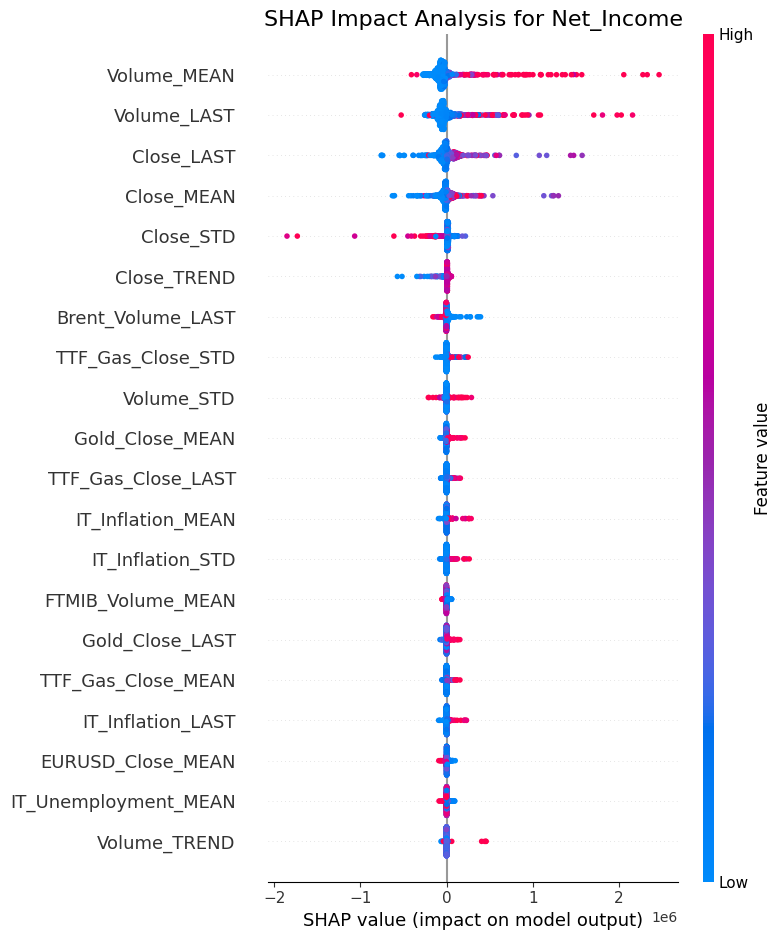


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected)  0.770594 1.330620e+06 357376.189361    804.712560        62.514378 45.766864  80.629700
       ROA Signed-Log RF (selected) -0.265955 1.505590e-01      0.050977    222.164454        78.912944 92.022689 108.277174
Net_Income Raw-Target RF (selected)  0.593393 7.090408e+05 202051.880708    501.240644        80.176871 63.038081 105.180169


In [ ]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=90)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 40:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    comparison_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_test_pred
    })
    comparison_df['Abs_Error'] = np.abs(comparison_df['Actual'] - comparison_df['Predicted'])
    comparison_df['Pct_Diff_%'] = (
        comparison_df['Abs_Error'] / np.maximum(np.abs(comparison_df['Actual']), 1e-8)
    ) * 100.0

    print(f"\nSample of predicted vs actual values for {target}:")
    print(comparison_df.head(12).to_string(index=False))

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()

    rf_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()

    shap_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

### YoY Exogenous Variables Only without one hot encoding of the company


                                EBITDA                                
Total valid 365-day windows extracted: 2138

Model comparison (test metrics):
Raw Target RF  -> R2: 0.5957 | MAE: 452025.5783 | RMSE: 1828890.6692 | Avg % Diff: 977.28% | WAPE: 57.00% | sMAPE: 84.69%
Signed-Log RF  -> R2: 0.1806 | MAE: 634132.6652 | RMSE: 2603468.6645 | Avg % Diff: 309.17% | WAPE: 79.97% | sMAPE: 103.61%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': None, 'criterion': 'squared_error', 'bootstrap': True}
Train -> MAE: 220591.7421 | RMSE: 843264.1613 | R2: 0.9007 | Avg % Diff: 338.31% | Median % Diff: 40.78% | WAPE: 27.61% | sMAPE: 60.93%
Test  -> MAE: 452025.5783 | RMSE: 1828890.6692 | R2: 0.5957 | Avg % Diff: 977.28% | Median % Diff: 71.46% | WAPE: 57.00% | sMAPE: 84.69%

Sample of predicted vs actual values for EBITDA:
   Actual     Predicted     Abs_Error  Pct_D

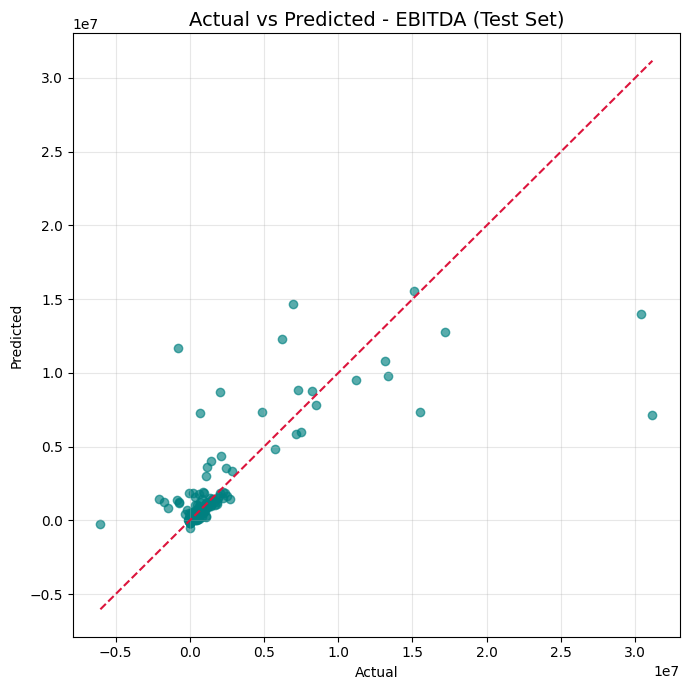

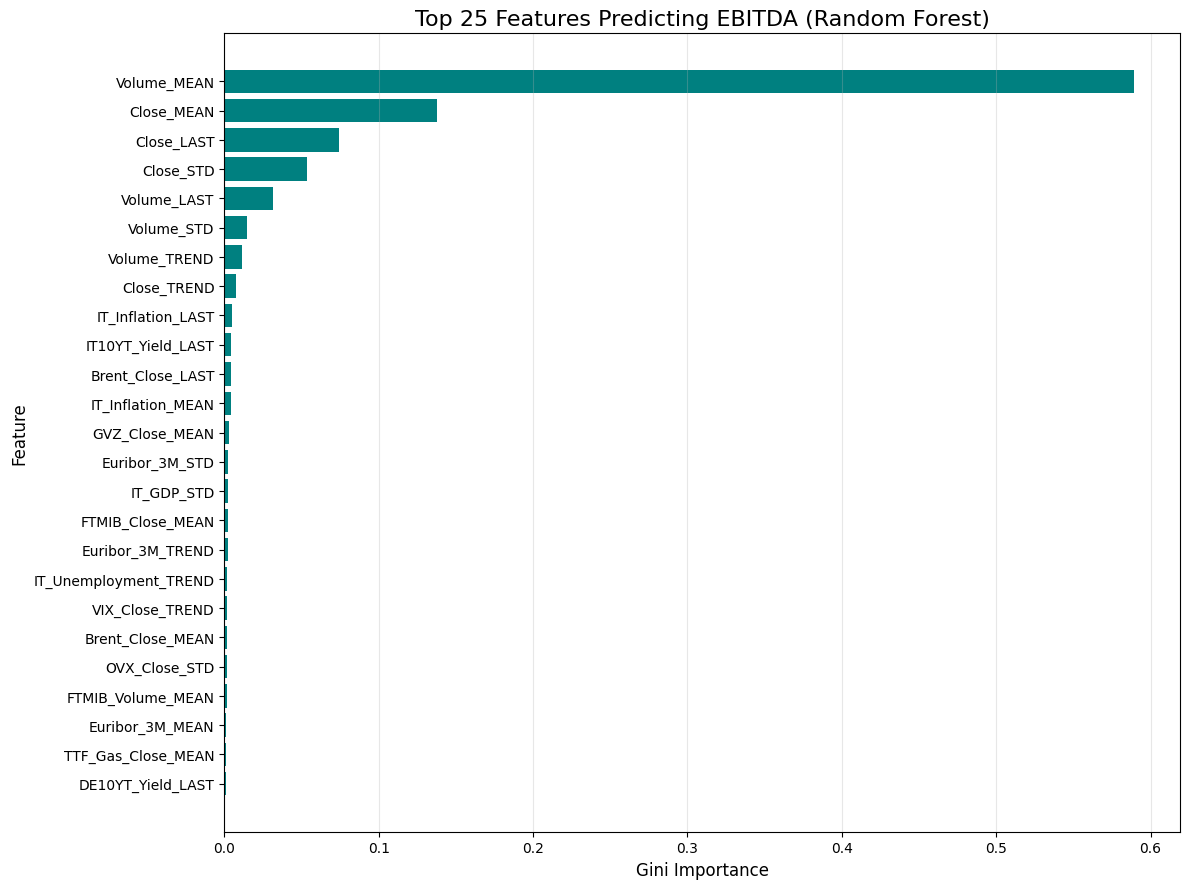

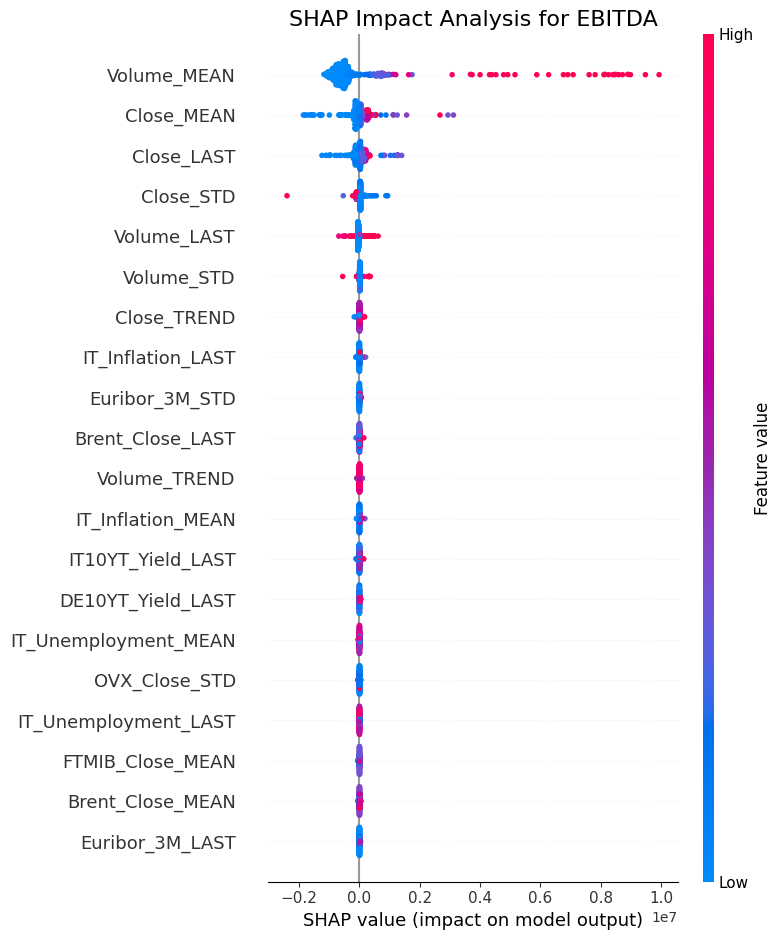


                                 ROA                                  
Total valid 365-day windows extracted: 2173

Model comparison (test metrics):
Raw Target RF  -> R2: -0.0356 | MAE: 0.1400 | RMSE: 1.4653 | Avg % Diff: 415.86% | WAPE: 97.49% | sMAPE: 110.76%
Signed-Log RF  -> R2: -0.0259 | MAE: 0.1373 | RMSE: 1.4584 | Avg % Diff: 388.01% | WAPE: 95.59% | sMAPE: 110.37%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0588 | RMSE: 0.7993 | R2: 0.0256 | Avg % Diff: 185.01% | Median % Diff: 51.13% | WAPE: 69.28% | sMAPE: 77.97%
Test  -> MAE: 0.1373 | RMSE: 1.4584 | R2: -0.0259 | Avg % Diff: 388.01% | Median % Diff: 88.97% | WAPE: 95.59% | sMAPE: 110.37%

Sample of predicted vs actual values for ROA:
   Actual  Predicted  Abs_Error  Pct_Diff_%
 0.002855   0.000195   0.002659   93.162053
 0.

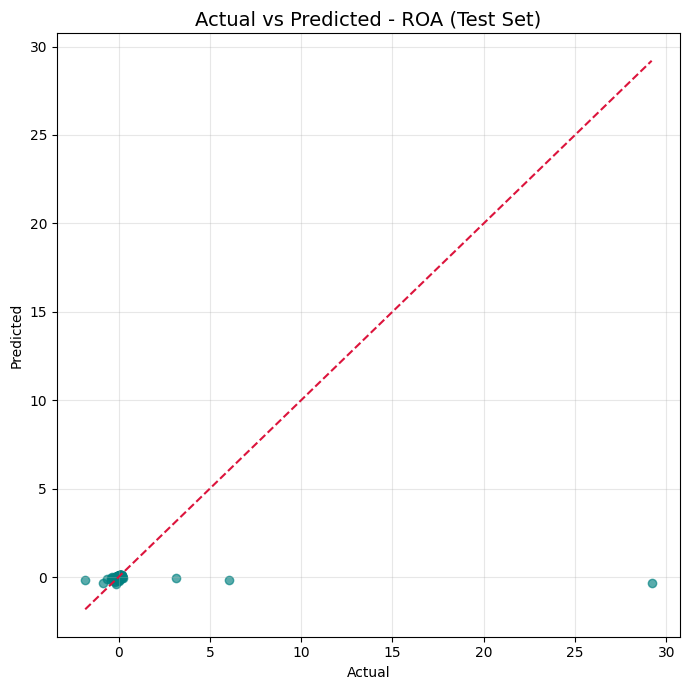

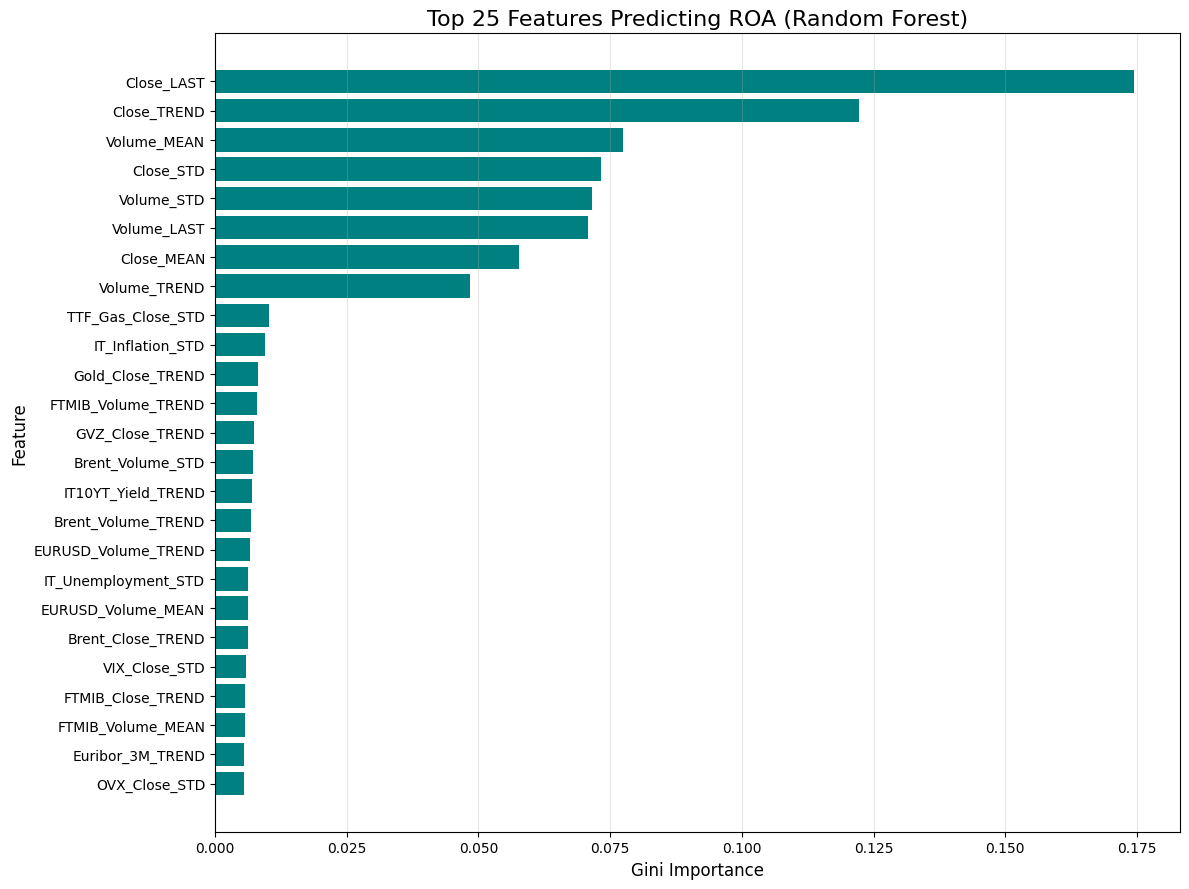

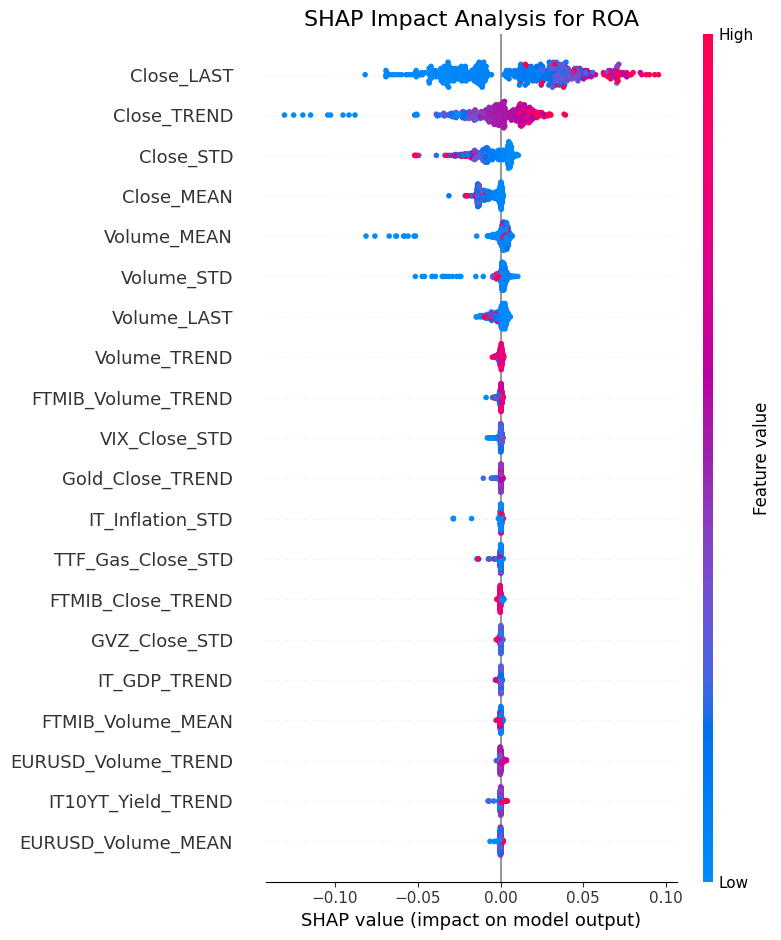


                              Net_Income                              
Total valid 365-day windows extracted: 2175

Model comparison (test metrics):
Raw Target RF  -> R2: 0.2881 | MAE: 207979.5587 | RMSE: 671868.2460 | Avg % Diff: 362.38% | WAPE: 75.57% | sMAPE: 104.74%
Signed-Log RF  -> R2: 0.1338 | MAE: 231287.2171 | RMSE: 741073.3655 | Avg % Diff: 118.33% | WAPE: 84.03% | sMAPE: 141.12%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 139043.1326 | RMSE: 587899.5703 | R2: 0.7973 | Avg % Diff: 909.40% | Median % Diff: 54.38% | WAPE: 40.24% | sMAPE: 83.70%
Test  -> MAE: 207979.5587 | RMSE: 671868.2460 | R2: 0.2881 | Avg % Diff: 362.38% | Median % Diff: 82.30% | WAPE: 75.57% | sMAPE: 104.74%

Sample of predicted vs actual values for Net_Income:
   Actual     Predicted     Abs_Er

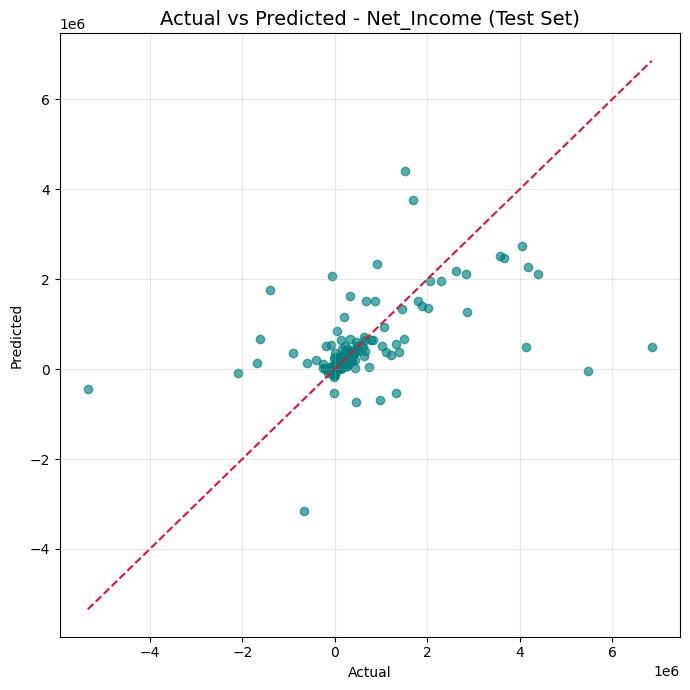

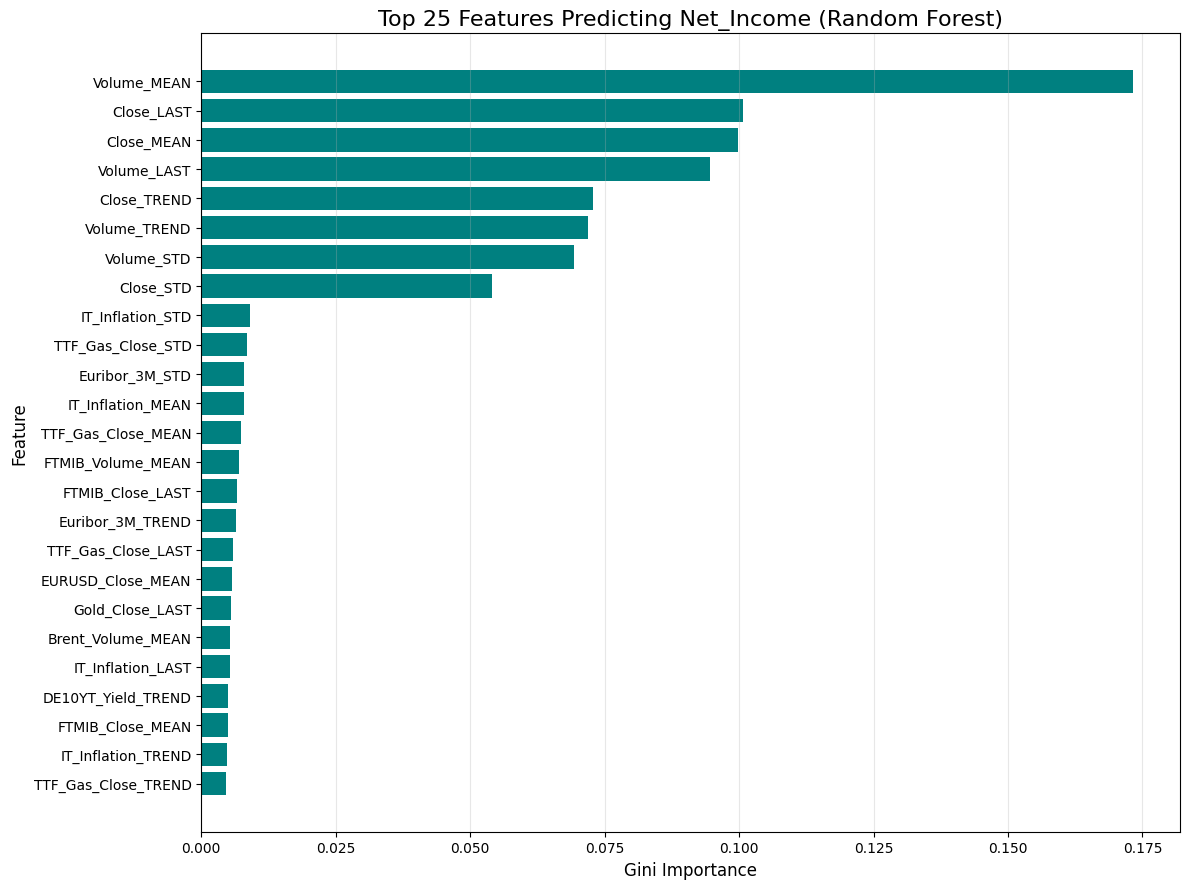

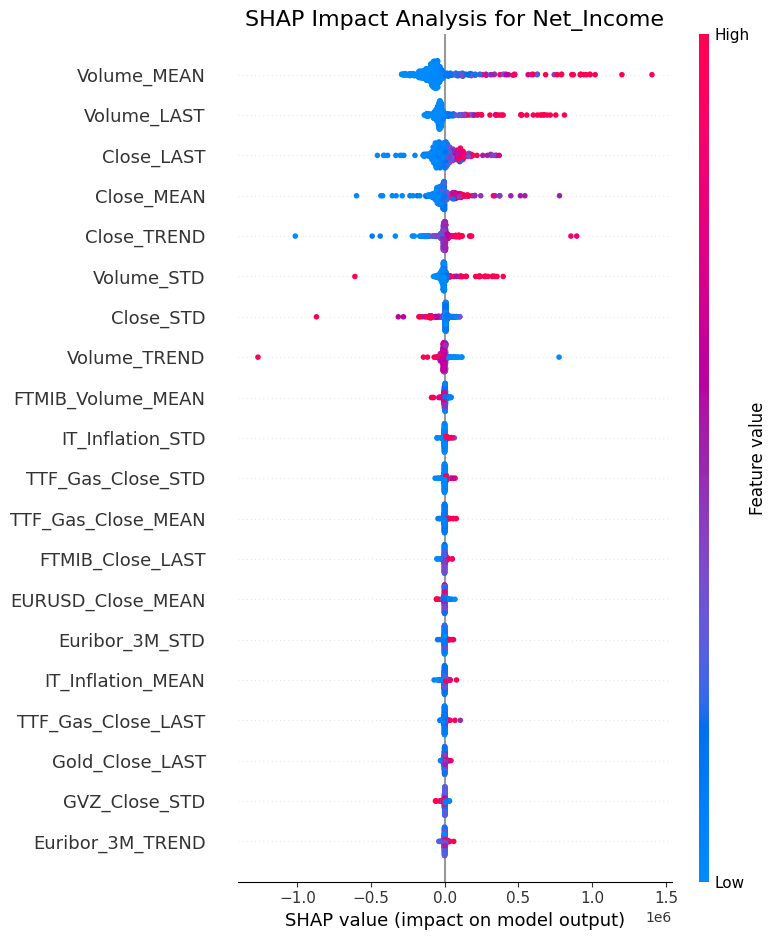


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected)  0.595650 1.828891e+06 452025.578298    977.278476        71.455253 57.003694  84.687612
       ROA Signed-Log RF (selected) -0.025924 1.458431e+00      0.137307    388.006698        88.968389 95.590061 110.373180
Net_Income Raw-Target RF (selected)  0.288059 6.718682e+05 207979.558683    362.375032        82.298403 75.565159 104.736133


In [ ]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 200:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    comparison_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_test_pred
    })
    comparison_df['Abs_Error'] = np.abs(comparison_df['Actual'] - comparison_df['Predicted'])
    comparison_df['Pct_Diff_%'] = (
        comparison_df['Abs_Error'] / np.maximum(np.abs(comparison_df['Actual']), 1e-8)
    ) * 100.0

    print(f"\nSample of predicted vs actual values for {target}:")
    print(comparison_df.head(12).to_string(index=False))

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()

    rf_save_path = f'../Analysis/Features Importance/YoY/Absolute Target/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()

    shap_save_path = f'../Analysis/Features Importance/YoY/Absolute Target/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 2: Log-Returns Target Analysis


In [ ]:
log_targets = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

for target in targets:
    new_target_name = f'{target}_LogReturn'
    log_targets.append(new_target_name)

    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    valid_reports[new_target_name] = valid_reports.groupby('Company')[target].transform(
        lambda x: (np.sign(x) * np.log1p(np.abs(x))) - (np.sign(x.shift(1)) * np.log1p(np.abs(x.shift(1))))
    )
    df_yoy[new_target_name] = valid_reports[new_target_name]

targets = log_targets

sample_check = df_yoy[df_yoy['EBITDA_LogReturn'].notna()]
print("\nSample of Annual EBITDA to EBITDA_LogReturn transformation:")
print(sample_check[['Company', 'Date', 'EBITDA', 'EBITDA_LogReturn']].head(10).to_string(index=False))


Sample of Annual EBITDA to EBITDA_LogReturn transformation:
Company       Date    EBITDA  EBITDA_LogReturn
    A2A 2010-12-30  696000.0         -0.176076
    A2A 2011-12-30  603000.0         -0.143432
    A2A 2012-12-28  984000.0          0.489708
    A2A 2013-12-30 1265000.0          0.251201
    A2A 2014-12-30  770000.0         -0.496436
    A2A 2015-12-30  611000.0         -0.231293
    A2A 2016-12-30  917000.0          0.406010
    A2A 2017-12-29 1099000.0          0.181048
    A2A 2018-12-28 1061000.0         -0.035189
    A2A 2019-12-30 1181000.0          0.107150



                           EBITDA_LogReturn                           
Total valid 365-day windows extracted: 2126

Best RF Params for EBITDA_LogReturn: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 2.0394 | RMSE: 5.6982 | R2: 0.1118 | Avg % Diff: 473841.00% | Median % Diff: 94.03% | WAPE: 93.84% | sMAPE: 136.15%
Test  -> MAE: 2.3881 | RMSE: 6.5013 | R2: -0.0136 | Avg % Diff: 242.23% | Median % Diff: 95.55% | WAPE: 104.14% | sMAPE: 133.29%


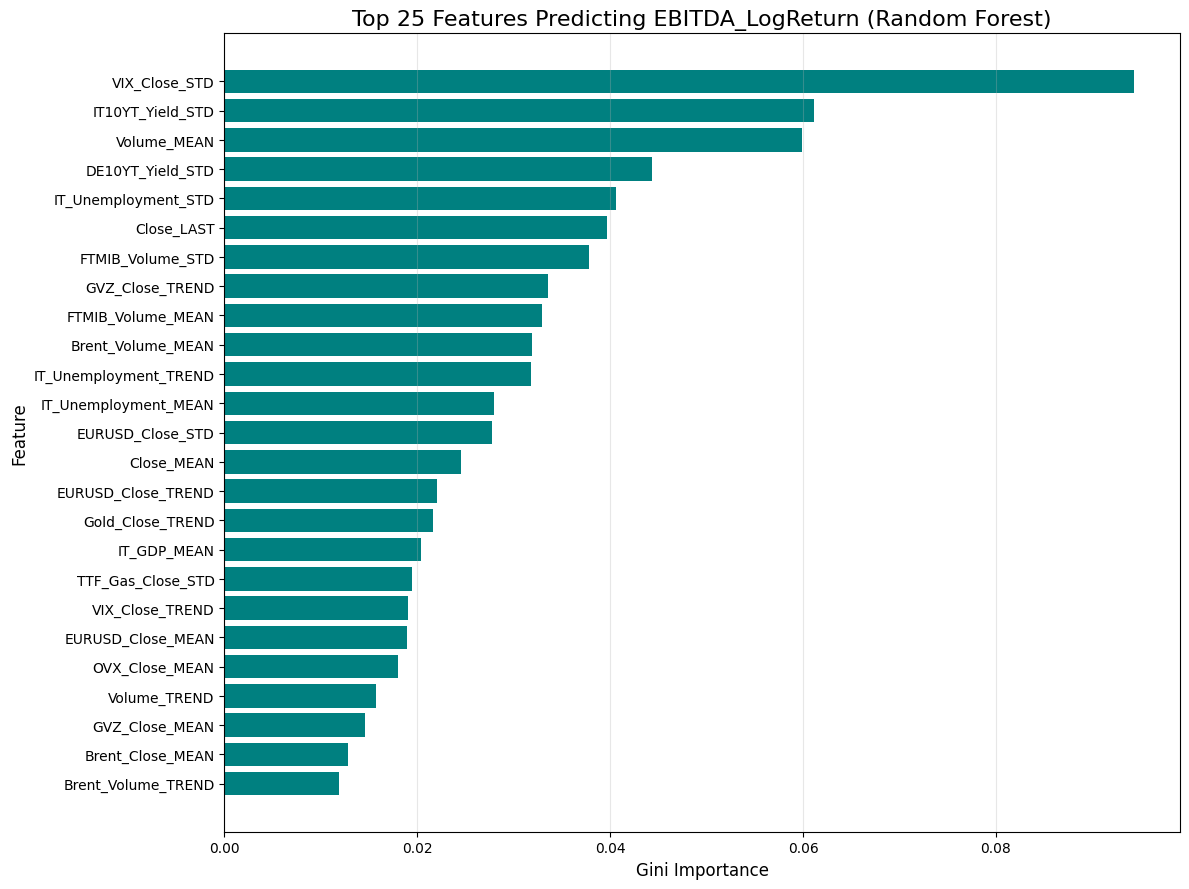

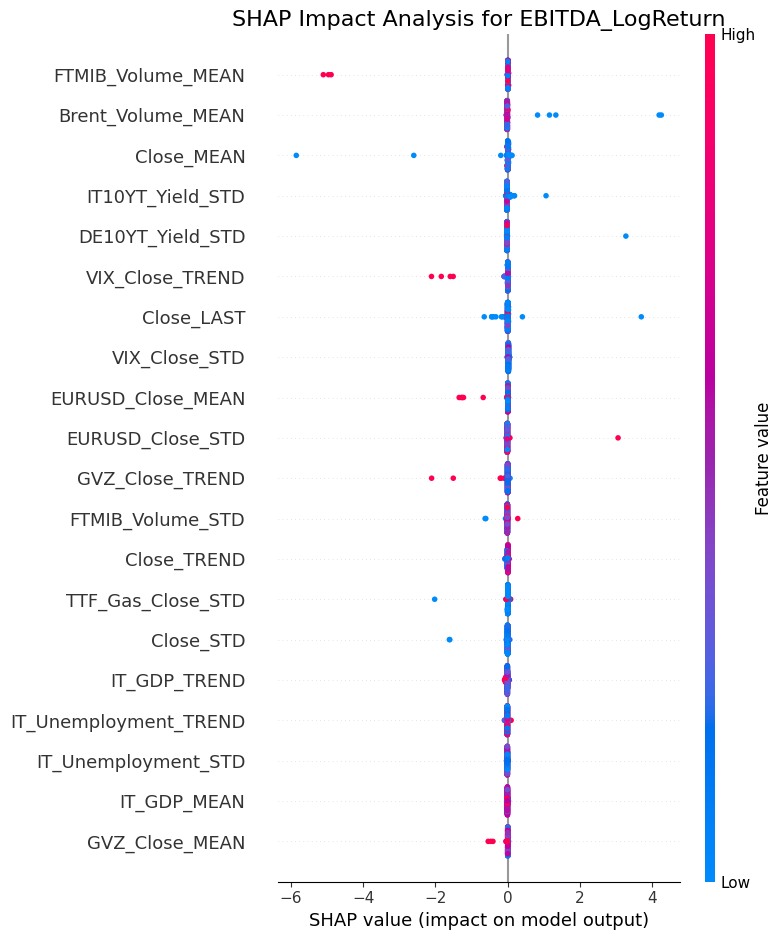


                            ROA_LogReturn                             
Total valid 365-day windows extracted: 2165

Best RF Params for ROA_LogReturn: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0430 | RMSE: 0.2180 | R2: 0.0786 | Avg % Diff: 262.96% | Median % Diff: 81.74% | WAPE: 84.59% | sMAPE: 117.29%
Test  -> MAE: 0.0433 | RMSE: 0.0948 | R2: 0.0037 | Avg % Diff: 339968.46% | Median % Diff: 100.62% | WAPE: 101.72% | sMAPE: 143.47%


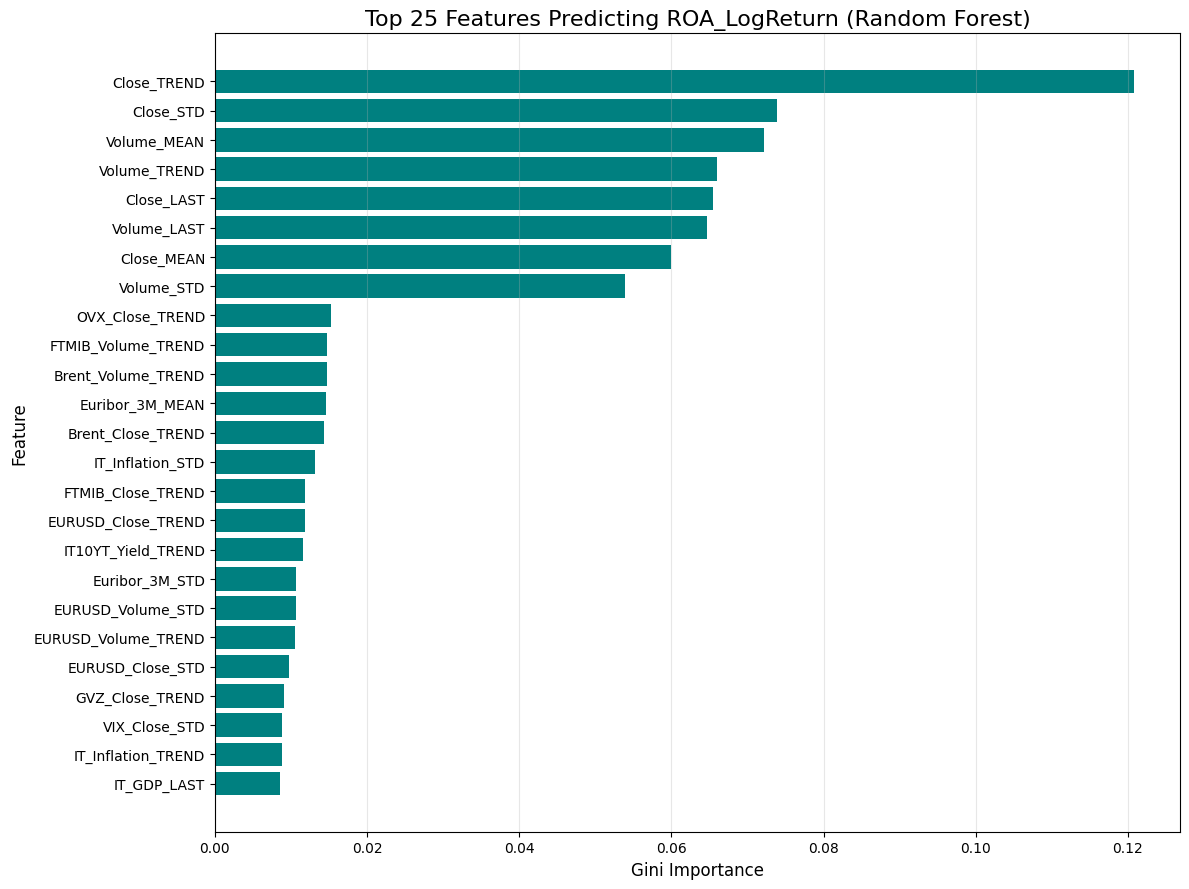

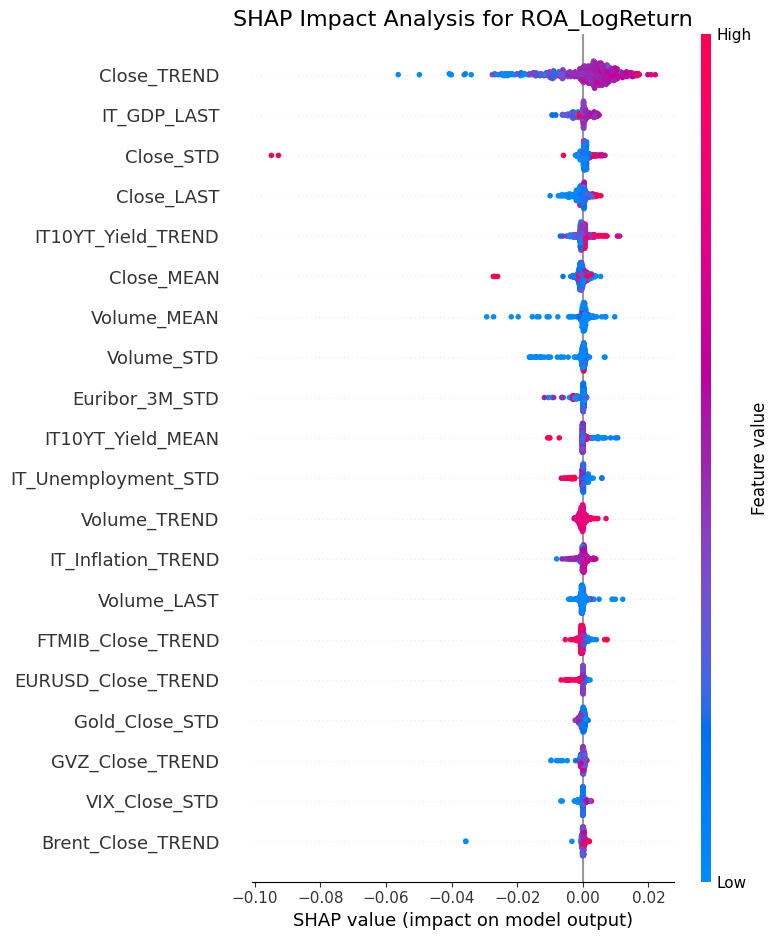


                         Net_Income_LogReturn                         
Total valid 365-day windows extracted: 2167

Best RF Params for Net_Income_LogReturn: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 3.5251 | RMSE: 7.6787 | R2: 0.1092 | Avg % Diff: 550778.96% | Median % Diff: 96.89% | WAPE: 94.89% | sMAPE: 145.46%
Test  -> MAE: 4.4041 | RMSE: 8.8320 | R2: -0.0127 | Avg % Diff: 463.07% | Median % Diff: 99.64% | WAPE: 104.18% | sMAPE: 151.97%


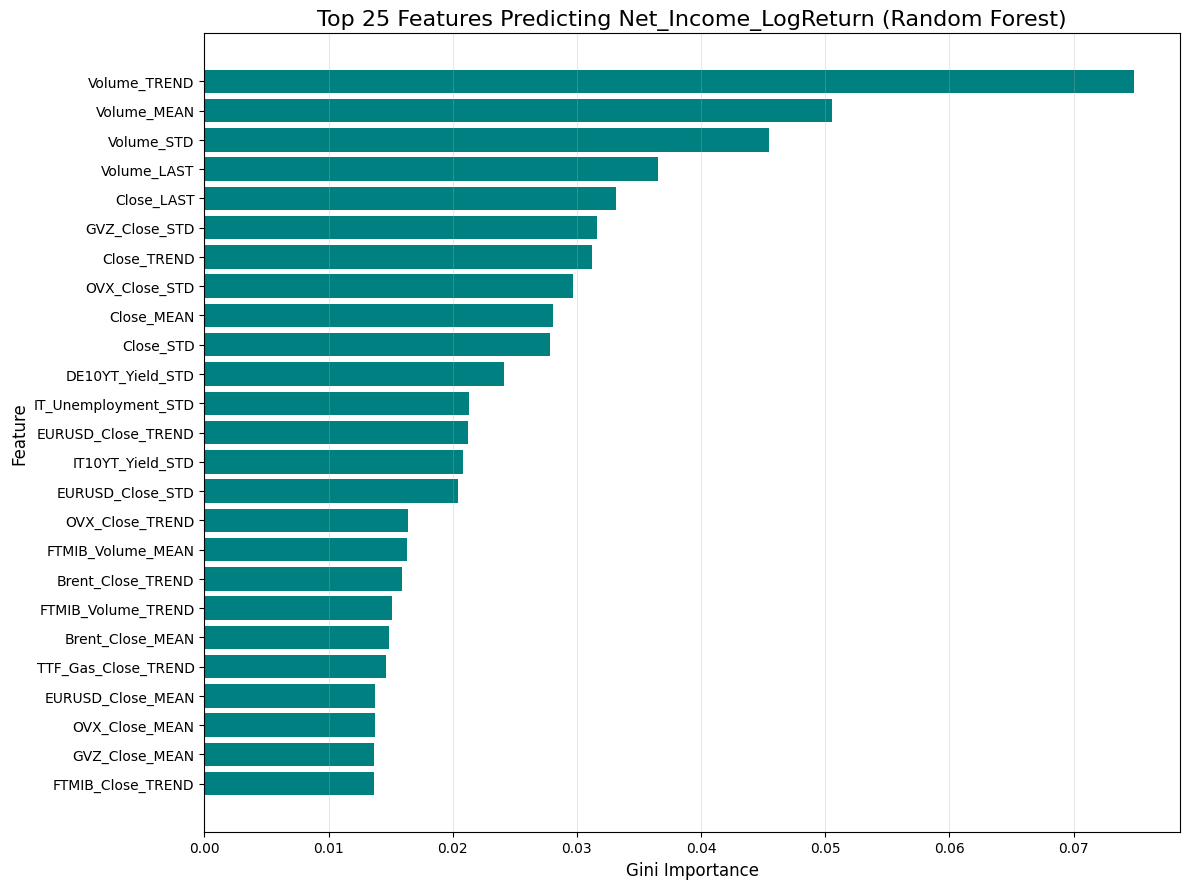

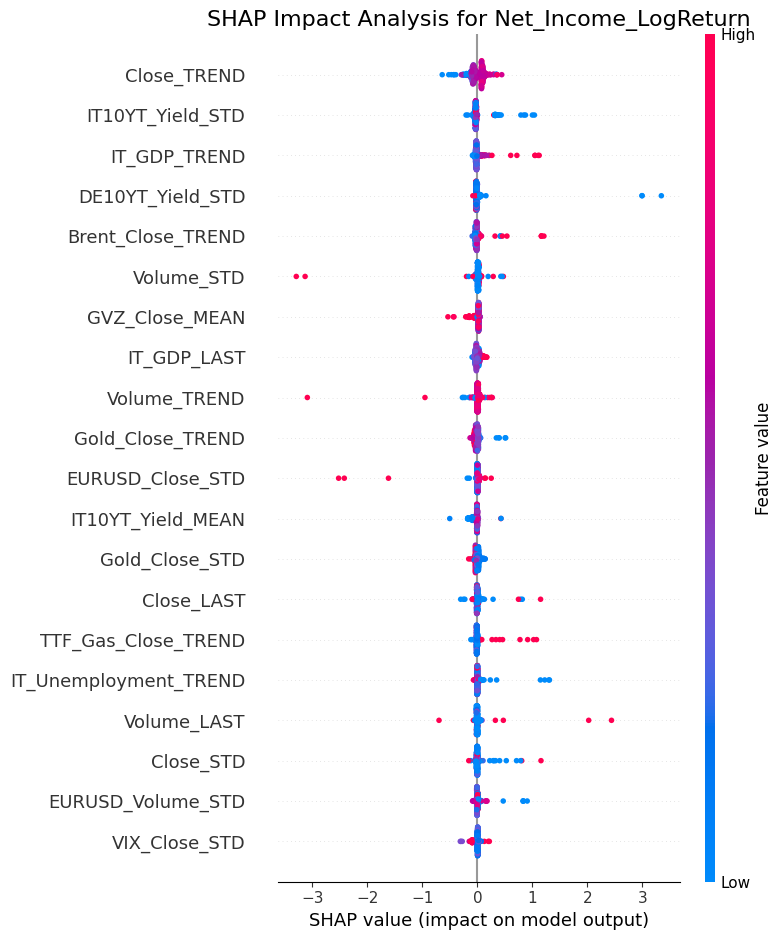


Final Test Performance Summary (Momentum Models)
              Target   Test_R2  Test_RMSE  Test_MAE  AvgPctDiff_%  MedianPctDiff_%     WAPE_%    sMAPE_%
    EBITDA_LogReturn -0.013591   6.501346  2.388059    242.227391        95.554042 104.144361 133.287996
       ROA_LogReturn  0.003747   0.094823  0.043298 339968.456924       100.615676 101.722485 143.465912
Net_Income_LogReturn -0.012662   8.832047  4.404059    463.068482        99.639687 104.179061 151.974719


In [ ]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    # 1. Extract the 365-day macro windows for each valid target
    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            # Full YoY window (365 days)
            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            # Ensure we have enough trading days in the year to calculate valid stats
            if len(window) <= 200:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # Remove the entity bias (Company ID) for pure macro evaluation
    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    # 2. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    # 3. Fit a single, robust Random Forest for Momentum Prediction
    # NOTE: ensure fit_rf and regression_metrics are defined in your notebook
    rf, best_params = fit_rf(X_train, y_train.values)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_metrics = regression_metrics(y_train.values, y_train_pred)
    test_metrics = regression_metrics(y_test.values, y_test_pred)

    print(f"\nBest RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # 4. Feature Importance Plot
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (Momentum Models)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 3: Momentum and Directional Forecasting

The results from Part 1 reveal a critical structural bias in predicting absolute financial variables, commonly known as the "Size Trap". 
For raw targets like EBITDA and Net Income, the models assigned overwhelming importance to trading volumes (`Volume_MEAN` and `Volume_STD`). Because the dataset contains both Small Cap and Large Cap companies, the algorithm stops analyzing financial performance and instead uses Volume as a proxy for Market Capitalization. It essentially learns a basic heuristic: companies with high trading volumes are massive, therefore their EBITDA will be in the billions.

To build a true predictive model that evaluates economic performance rather than company scale, the target variables are changed using two key transformations:
1. **Quarter-over-Quarter (QoQ) Momentum:** Instead of predicting the absolute level of the fundamentals, we calculate the percentage change compared to the previous quarter. A +5% growth is mathematically identical for a multi-national corporation and a local startup, effectively neutralizing the size bias.
2. **Directional Target (Classification):** the QoQ momentum is further refined into a binary target: **1 (Up)** if the fundamental improved, and **0 (Down)** if it worsened. 

By shifting the architecture from Regression to **Binary Classification**, we force the algorithms to ignore the company's size and focus exclusively on the macroeconomic drivers and market signals that dictate economic expansion or contraction.


                         EBITDA_Direction_Up                          
Total valid 365-day windows extracted for classification: 2126
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for EBITDA_Direction_Up: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 1.0}

--- Test Set Performance ---
Accuracy: 0.5634
ROC-AUC:  0.6387

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.60      0.50       156
           1       0.70      0.54      0.61       270

    accuracy                           0.56       426
   macro avg       0.57      0.57      0.56       426
weighted avg       0.60      0.56      0.57       426



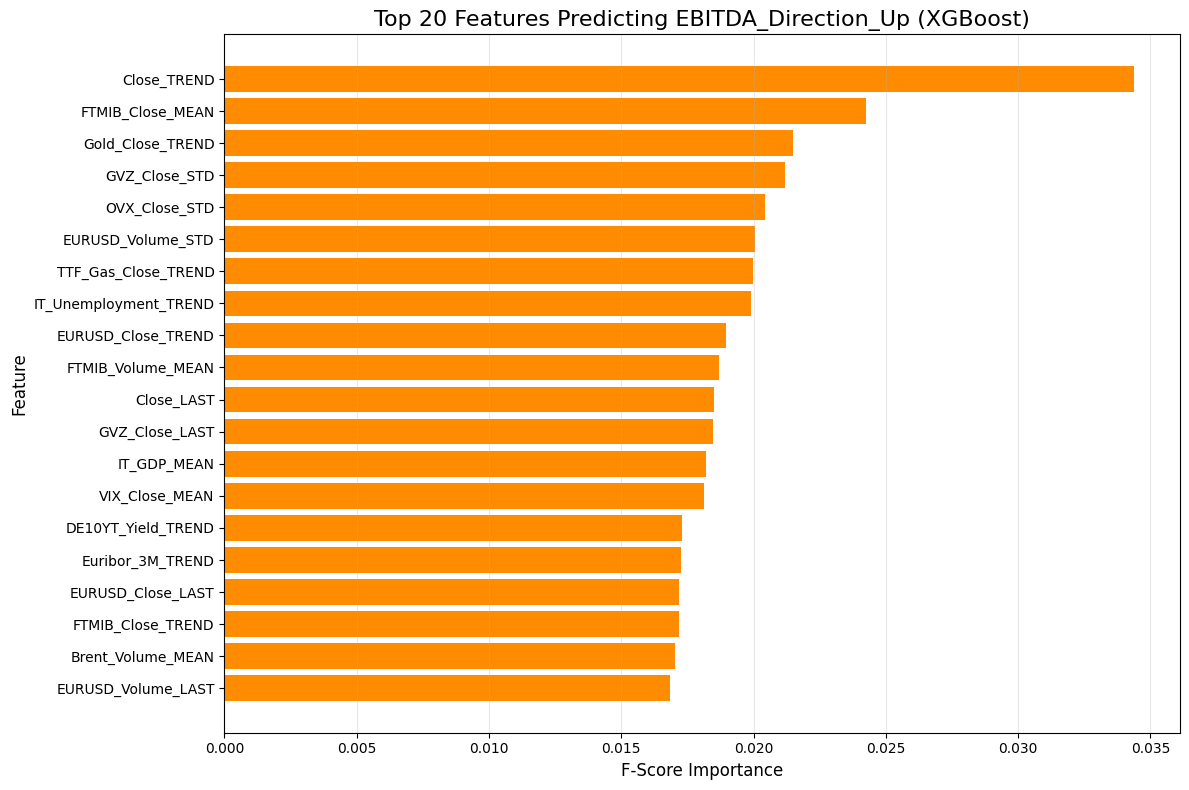

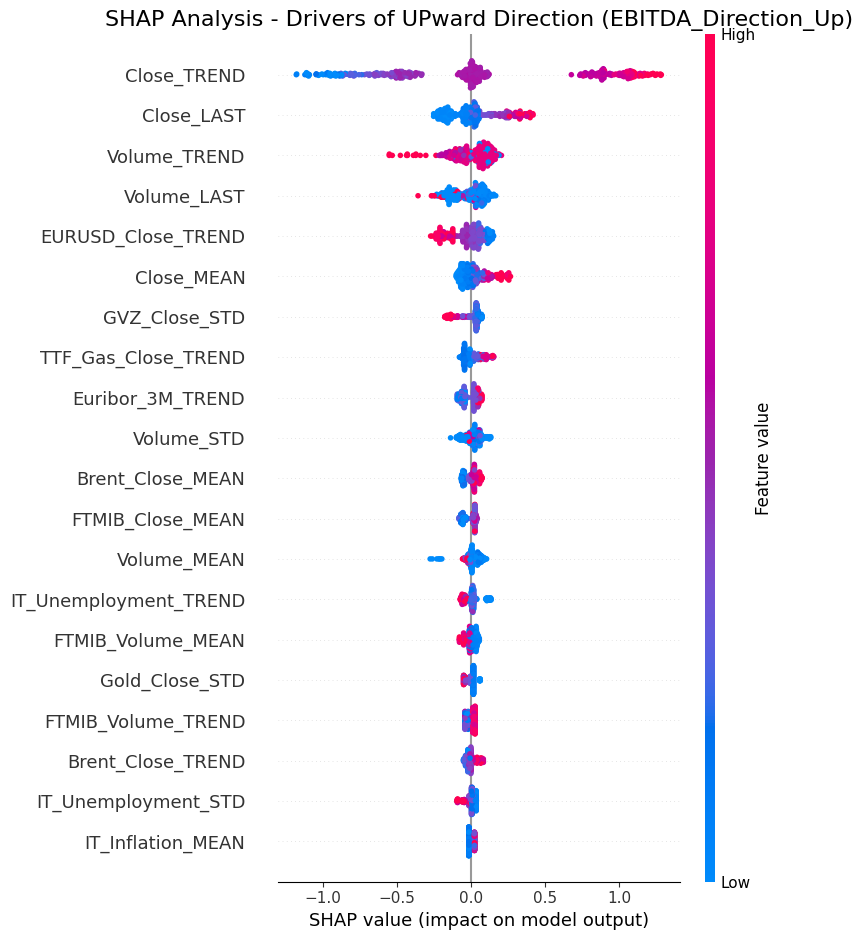


                           ROA_Direction_Up                           
Total valid 365-day windows extracted for classification: 2165
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for ROA_Direction_Up: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.6}

--- Test Set Performance ---
Accuracy: 0.6189
ROC-AUC:  0.6663

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.64      0.61       206
           1       0.65      0.60      0.62       227

    accuracy                           0.62       433
   macro avg       0.62      0.62      0.62       433
weighted avg       0.62      0.62      0.62       433



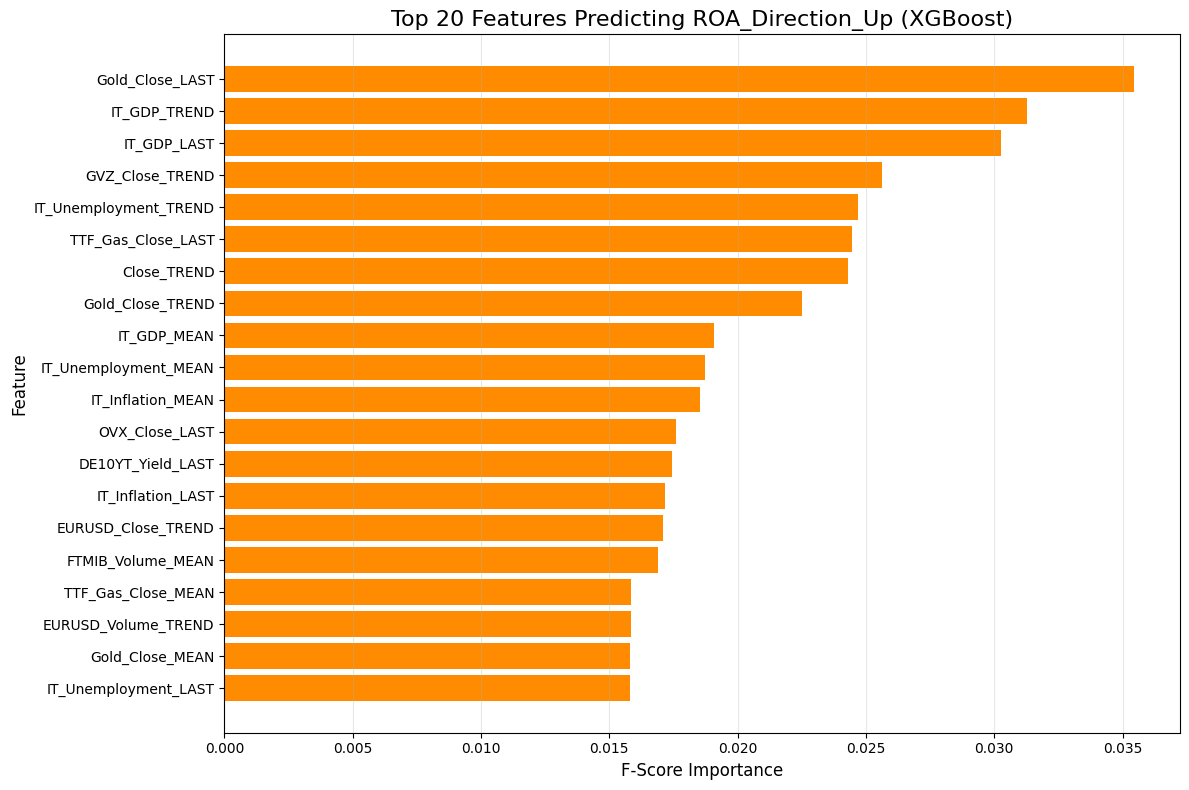

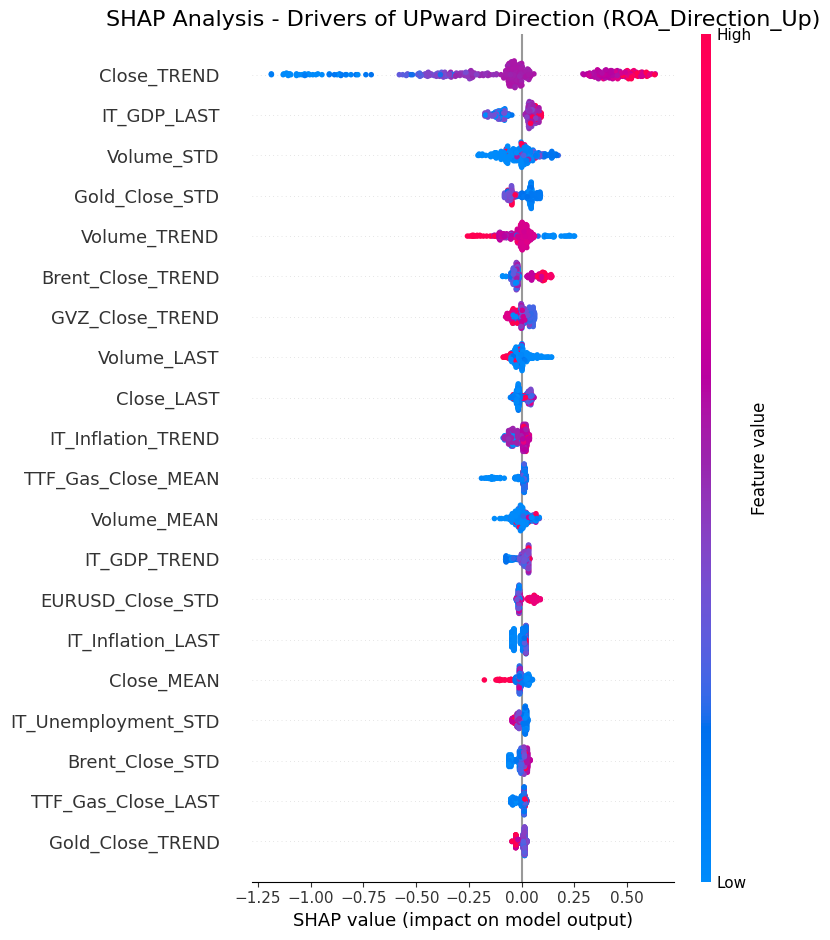


                       Net_Income_Direction_Up                        
Total valid 365-day windows extracted for classification: 2167
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for Net_Income_Direction_Up: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.8}

--- Test Set Performance ---
Accuracy: 0.5876
ROC-AUC:  0.6439

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       175
           1       0.69      0.56      0.62       259

    accuracy                           0.59       434
   macro avg       0.59      0.60      0.59       434
weighted avg       0.61      0.59      0.59       434



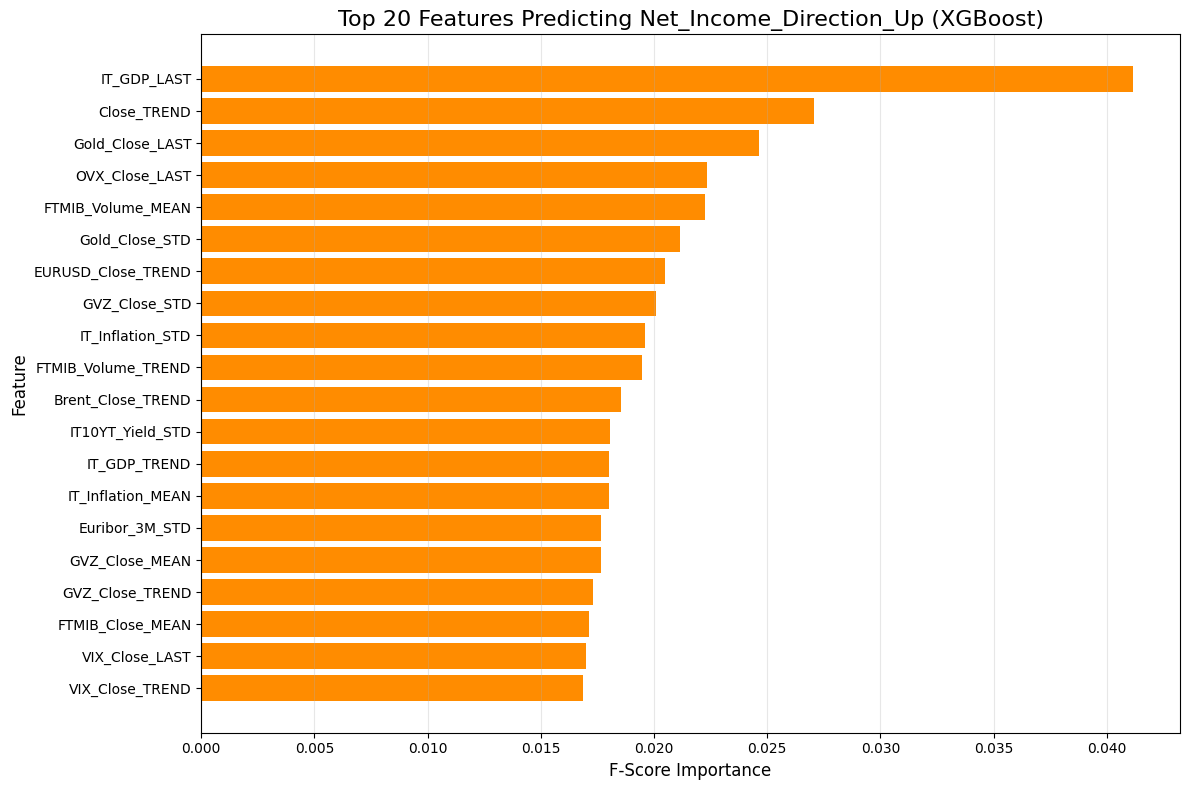

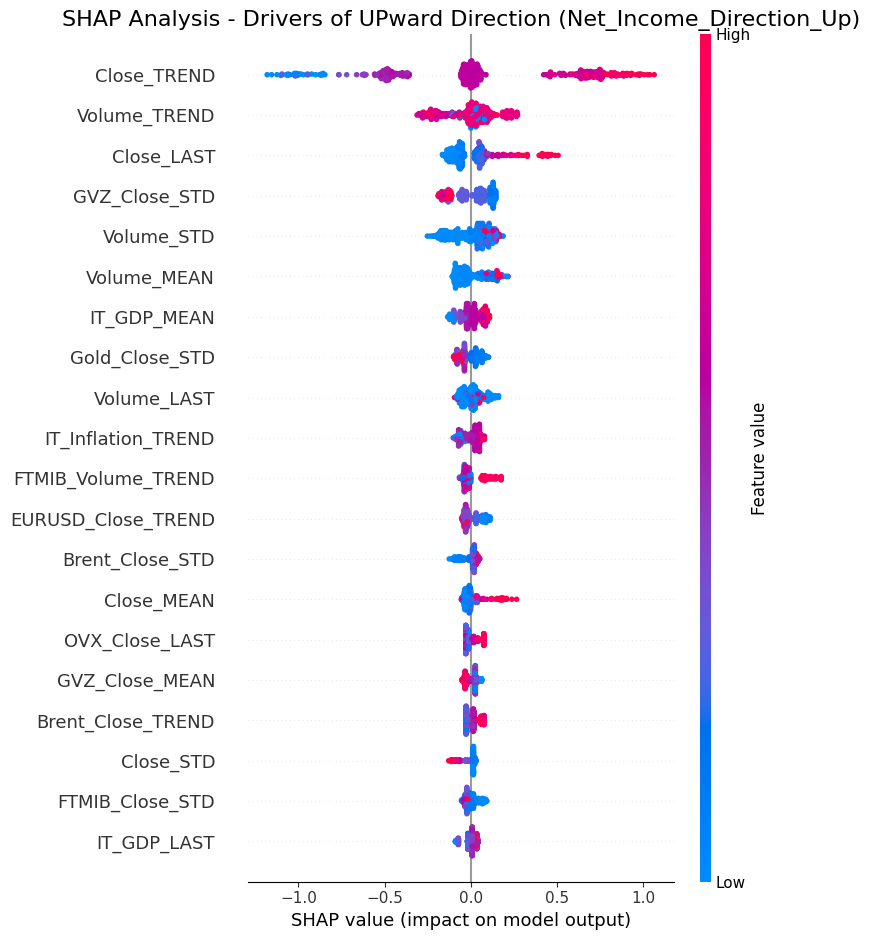


Final Test Performance Summary (XGBoost Classification Models)
                 Target  Test_Accuracy  Test_ROC_AUC
    EBITDA_Direction_Up       0.563380      0.638711
       ROA_Direction_Up       0.618938      0.666300
Net_Income_Direction_Up       0.587558      0.643916


In [7]:
performance_summary = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

directional_targets = []

for target in targets:
    dir_col = f"{target}_Direction_Up"
    directional_targets.append(dir_col)
    
    # Isolate ONLY the valid yearly reports (ignore the daily NaNs)
    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    
    # Calculate Direction: Current Year minus Previous Year.
    # If > 0, it means the company grew (UP = 1). Otherwise (DOWN/FLAT = 0).
    valid_reports[dir_col] = valid_reports.groupby('Company')[target].transform(
        lambda x: np.where(x - x.shift(1) > 0, 1, 0)
    )
    
    # The first year of a company has no previous year to compare to, so it must be NaN
    valid_reports.loc[valid_reports.groupby('Company')[target].shift(1).isna(), dir_col] = np.nan
    
    # Map the UP/DOWN flags safely back to the daily dataframe
    df_yoy[dir_col] = valid_reports[dir_col]

# ---------------------------------------------------------
# 2. Main Execution Loop (Data Prep & Modeling)
# ---------------------------------------------------------
# Pre-grouping for performance to avoid slow pandas filtering
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    # Extract the 365-day macro windows
    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]
            
            # FULL YEAR macro window
            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]
            
            # Ensure we have enough trading days for robust statistics
            if len(window) > 200:
                window_stats = {}
                for feat in features:
                    series = window[feat].dropna()
                    if series.empty:
                        window_stats[f"{feat}_MEAN"] = 0.0
                        window_stats[f"{feat}_STD"] = 0.0
                        window_stats[f"{feat}_LAST"] = 0.0
                        window_stats[f"{feat}_TREND"] = 0.0
                    else:
                        values = series.values.astype(float)
                        window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                        window_stats[f"{feat}_STD"] = float(np.std(values))
                        window_stats[f"{feat}_LAST"] = float(values[-1])
                        
                        if len(values) > 1:
                            x_axis = np.arange(len(values), dtype=float)
                            slope = np.polyfit(x_axis, values, deg=1)[0]
                        else:
                            slope = 0.0
                        window_stats[f"{feat}_TREND"] = float(slope)

                X_aggregated.append(window_stats)
                y_values.append(int(target_value))

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 365-day windows extracted for classification: {len(X_df)}")
    if len(X_df) < 50:
        print("Not enough samples. Skipping.")
        continue

    # Train/Test Split (Stratified to maintain class ratios)
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42, stratify=y_series
    )
    
    # Scale ONLY after splitting to prevent Data Leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit the XGBoost model with Hyperparameter Tuning
    xgb_model, best_params = fit_xgb_classifier(X_train_scaled, y_train)
    print(f"Best XGB Params for {target}: {best_params}")
    
    # Predictions & Metrics on TEST SET (Out-of-Sample)
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n--- Test Set Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    performance_summary.append({
        'Target': target,
        'Best_Params': str(best_params),
        'Test_Accuracy': accuracy,
        'Test_ROC_AUC': roc_auc
    })

    # XGBoost Feature Importance Plot (Weight / F-Score)
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='darkorange')
    plt.title(f'Top 20 Features Predicting {target} (XGBoost)', fontsize=16)
    plt.xlabel('F-Score Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Impact Plot
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Handle SHAP output format variations between different library versions
    if isinstance(shap_values, list):
        shap_values_target = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_target = shap_values[:, :, 1]
    else:
        shap_values_target = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Analysis - Drivers of UPward Direction ({target})", fontsize=16)
    shap.summary_plot(shap_values_target, X_test, feature_names=X_test.columns, plot_type="dot", show=False)
    plt.tight_layout()
    plt.show()

# Final Output
performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (XGBoost Classification Models)")
print("=" * 70)
print(performance_summary_df[['Target', 'Test_Accuracy', 'Test_ROC_AUC']].to_string(index=False))